# Interpretable Scientific Discovery with Symbolic Regression: A Review

**Paper:** Makke, N., & Chawla, S. (2024). *Interpretable scientific discovery with symbolic regression: a review.* Artificial Intelligence Review, 57, 2. arXiv:2211.10873.

**Carpeta origen:** `Papers/02_Interpretabilidad_y_Explicabilidad/Makke_Chawla_2022_Interpretable_Scientific_Discovery_SR_Review.pdf`

## Que se reproduce en este cuaderno

Este es un articulo de revision: no propone un algoritmo propio, sino que **clasifica** los metodos de regresion simbolica existentes segun su estrategia de busqueda en el espacio de expresiones (evolutiva/genetica, enumerativa/de fuerza bruta, basada en diccionarios/voraz, basada en aprendizaje profundo) y analiza como cada familia controla el compromiso entre precision y complejidad.

En vez de solo describir la taxonomia en texto, la hacemos **tangible**: implementamos tres paradigmas de busqueda representativos y los enfrentamos al **mismo problema exacto**, disenado deliberadamente para que ningun paradigma domine en todos los aspectos -- exactamente el tipo de matiz que una revision seria debe capturar:

$$f(x_0,x_1) = x_0\sin(x_1) + x_0^2$$

Esta funcion requiere un **termino multiplicativo cruzado** ($x_0\sin(x_1)$), lo que la convierte en un caso de prueba revelador de las fortalezas y debilidades estructurales de cada paradigma.

## Repositorio publico

Al ser una revision, el paper no distribuye un unico repositorio de codigo propio; cataloga y referencia decenas de herramientas de terceros (algunas ya usadas en cuadernos anteriores de esta coleccion: PySR, y en el proximo bloque de cuadernos, DSR/deep-symbolic-optimization y NeSymReS). Aqui reimplementamos representantes minimos de cada paradigma que discute la revision, no una herramienta especifica del catalogo.

In [1]:
%pip install -q numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. El problema de prueba

In [2]:
import numpy as np
import random
import itertools
import time
import matplotlib.pyplot as plt

random.seed(0)
np.random.seed(0)

def target_f(X):
    x0, x1 = X[:, 0], X[:, 1]
    return x0 * np.sin(x1) + x0 ** 2

N = 150
X = np.column_stack([np.random.uniform(-2, 2, N), np.random.uniform(-2, 2, N)])
y = target_f(X)

OPS1 = {'sin': np.sin, 'square': lambda a: a ** 2}
OPS2 = {'+': lambda a, b: a + b, '*': lambda a, b: a * b}
NVARS = 2
print(f'Objetivo: f(x0,x1) = x0*sin(x1) + x0^2   |   {N} puntos de entrenamiento')

Objetivo: f(x0,x1) = x0*sin(x1) + x0^2   |   150 puntos de entrenamiento


## 2. Paradigma A: enumeracion exhaustiva de fuerza bruta

Enumeramos **todas** las combinaciones posibles de sumas de hasta 3 "atomos" simples (una variable, o un operador unario aplicado a una variable). Es exhaustivo dentro de su gramatica -- garantiza encontrar el optimo **si la solucion existe dentro de esa gramatica** -- pero la gramatica elegida (solo sumas de terminos univariados) **no puede representar** un termino cruzado como $x_0\sin(x_1)$, sin importar cuanto busquemos.

In [3]:
def enumerate_trees(max_atoms):
    atoms = [('var', i) for i in range(NVARS)]
    for name in OPS1:
        for i in range(NVARS):
            atoms.append(('op1', name, i))
    results = []
    for r in range(1, max_atoms + 1):
        for combo in itertools.combinations_with_replacement(range(len(atoms)), r):
            results.append([atoms[i] for i in combo])
    return results

def eval_combo(combo, X):
    total = np.zeros(X.shape[0])
    for atom in combo:
        total = total + (X[:, atom[1]] if atom[0] == 'var' else OPS1[atom[1]](X[:, atom[2]]))
    return total

t0 = time.time()
combos = enumerate_trees(3)
best_bf, best_err = None, np.inf
for combo in combos:
    err = np.mean((eval_combo(combo, X) - y) ** 2)
    if err < best_err:
        best_err, best_bf = err, combo
t_bf = time.time() - t0

print(f'Combinaciones evaluadas: {len(combos)}  |  tiempo: {t_bf:.4f}s  |  mejor MSE: {best_err:.4f}')
print('>>> Limitacion estructural: su gramatica solo admite sumas de terminos univariados,')
print('    por lo que NO puede representar x0*sin(x1) sin importar cuanto se busque.')

Combinaciones evaluadas: 83  |  tiempo: 0.0041s  |  mejor MSE: 0.7807
>>> Limitacion estructural: su gramatica solo admite sumas de terminos univariados,
    por lo que NO puede representar x0*sin(x1) sin importar cuanto se busque.


## 3. Paradigma B: programacion genetica

Poblacion de arboles de expresion con mutacion y cruce, evolucionando sobre una gramatica que **si** incluye multiplicacion. Puede construir estructuras compuestas nuevas (compositional), a costa de necesitar muchas mas evaluaciones y sin garantia de encontrar el optimo global.

In [4]:
def random_leaf():
    return ('var', random.randrange(NVARS)) if random.random() < 0.6 else ('const', round(random.uniform(-2, 2), 2))

def random_tree(depth):
    if depth <= 0 or random.random() < 0.25:
        return random_leaf()
    if random.random() < 0.35:
        return ('op1', random.choice(list(OPS1)), [random_tree(depth - 1)])
    return ('op2', random.choice(list(OPS2)), [random_tree(depth - 1), random_tree(depth - 1)])

def ev(node, X):
    if node[0] == 'var': return X[:, node[1]]
    if node[0] == 'const': return np.full(X.shape[0], node[1])
    if node[0] == 'op1': return OPS1[node[1]](ev(node[2][0], X))
    return OPS2[node[1]](ev(node[2][0], X), ev(node[2][1], X))

def mut(n, d=3):
    if random.random() < 0.4:
        return random_tree(d)
    if n[0] in ('op1', 'op2'):
        return (n[0], n[1], [mut(c, d - 1) for c in n[2]])
    return n

def xover(a, b):
    def nodes(n, path=()):
        yield path, n
        if n[0] in ('op1', 'op2'):
            for k, c in enumerate(n[2]):
                yield from nodes(c, path + (k,))
    def clone(n):
        if n[0] in ('var', 'const'): return n
        return (n[0], n[1], [clone(c) for c in n[2]])
    def setp(root, path, new):
        if not path: return new
        root = clone(root); cur = root
        for p in path[:-1]: cur = cur[2][p]
        cur[2][path[-1]] = new
        return root
    pa, _ = random.choice(list(nodes(a)))
    _, sb = random.choice(list(nodes(b)))
    return setp(a, pa, sb)

t0 = time.time()
pop = [random_tree(3) for _ in range(40)]
n_evals = 0
best_gp, best_gp_err = None, np.inf
for gen in range(150):
    scored = []
    for ind in pop:
        try:
            err = np.mean((ev(ind, X) - y) ** 2); n_evals += 1
        except Exception:
            err = np.inf
        scored.append((err, ind))
    scored.sort(key=lambda t: t[0])
    if scored[0][0] < best_gp_err:
        best_gp_err, best_gp = scored[0]
    newpop = [ind for _, ind in scored[:6]]
    while len(newpop) < 40:
        if random.random() < 0.3:
            p1, p2 = random.choice(scored[:15])[1], random.choice(scored[:15])[1]
            newpop.append(xover(p1, p2))
        else:
            newpop.append(mut(random.choice(scored[:15])[1]))
    pop = newpop
t_gp = time.time() - t0

print(f'Expresiones evaluadas: {n_evals}  |  tiempo: {t_gp:.4f}s  |  mejor MSE: {best_gp_err:.6f}')
print('>>> A diferencia de la enumeracion, SI puede construir el termino cruzado x0*sin(x1),')
print('    pero necesita miles de evaluaciones estocasticas para converger.')

Expresiones evaluadas: 6000  |  tiempo: 0.4924s  |  mejor MSE: 0.000000
>>> A diferencia de la enumeracion, SI puede construir el termino cruzado x0*sin(x1),
    pero necesita miles de evaluaciones estocasticas para converger.


## 4. Paradigma C: seleccion voraz sobre un diccionario de terminos

En cada paso, anade a la formula el termino de una biblioteca predefinida que mas reduce el error (ajustando los coeficientes por minimos cuadrados), un enfoque tipico de los metodos de "diccionario"/basados en biblioteca que discute la revision. Probamos **dos** versiones: una biblioteca que **no** incluye el termino cruzado $x_0\sin(x_1)$, y otra que si lo incluye.

In [5]:
DICT_missing = {'x0': lambda X: X[:, 0], 'x1': lambda X: X[:, 1], 'x0^2': lambda X: X[:, 0] ** 2,
                'x1^2': lambda X: X[:, 1] ** 2, 'sin(x0)': lambda X: np.sin(X[:, 0]), 'sin(x1)': lambda X: np.sin(X[:, 1])}
DICT_full = dict(DICT_missing)
DICT_full['x0*sin(x1)'] = lambda X: X[:, 0] * np.sin(X[:, 1])

def greedy_search(DICT, X, y, max_terms=4):
    selected, remaining = [], list(DICT.keys())
    best = np.inf
    t0 = time.time(); n_evals = 0
    for step in range(max_terms):
        best_term, best_term_err = None, best
        for term in remaining:
            trial = selected + [term]
            A = np.column_stack([DICT[t](X) for t in trial])
            coefs, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
            err = np.mean((A @ coefs - y) ** 2); n_evals += 1
            if err < best_term_err:
                best_term_err, best_term = err, term
        if best_term is None or best_term_err >= best - 1e-9:
            break
        selected.append(best_term); remaining.remove(best_term); best = best_term_err
    return selected, best, time.time() - t0, n_evals

sel_missing, err_missing, t_missing, ne_missing = greedy_search(DICT_missing, X, y)
sel_full, err_full, t_full, ne_full = greedy_search(DICT_full, X, y)

print(f'Diccionario SIN termino cruzado -> terminos={sel_missing}, MSE={err_missing:.4f}')
print(f'Diccionario CON termino cruzado -> terminos={sel_full}, MSE={err_full:.6f}')
print('>>> El metodo voraz es extremadamente eficiente (pocas evaluaciones), pero es completamente')
print('    ciego a cualquier estructura que no este ya en su biblioteca predefinida.')

Diccionario SIN termino cruzado -> terminos=['x0^2', 'x1', 'sin(x1)', 'x1^2'], MSE=0.7469
Diccionario CON termino cruzado -> terminos=['x0^2', 'x0*sin(x1)'], MSE=0.000000
>>> El metodo voraz es extremadamente eficiente (pocas evaluaciones), pero es completamente
    ciego a cualquier estructura que no este ya en su biblioteca predefinida.


## 5. Tabla comparativa: la taxonomia hecha empirica

paradigma                            tiempo(s)   n_eval         MSE   observacion
Enumeracion exhaustiva (solo sumas)     0.0041       83    0.780691   Garantiza el optimo dentro de su gramatica; ciega a estructuras fuera de ella
Programacion genetica                   0.4924     6000    0.000000   Compositiva y flexible; estocastica, necesita muchas evaluaciones
Voraz (diccionario incompleto)          0.0050       18    0.746917   Muy eficiente; ciega a estructuras fuera de su biblioteca
Voraz (diccionario completo)            0.0039       18    0.000000   Optimo y muy eficiente SI la biblioteca ya contiene la estructura correcta


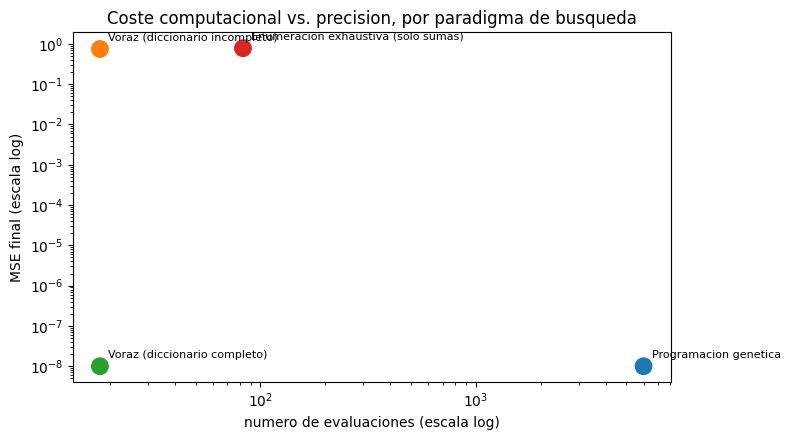

In [6]:
rows = [
    ('Enumeracion exhaustiva (solo sumas)', t_bf, len(combos), best_err, 'Garantiza el optimo dentro de su gramatica; ciega a estructuras fuera de ella'),
    ('Programacion genetica', t_gp, n_evals, best_gp_err, 'Compositiva y flexible; estocastica, necesita muchas evaluaciones'),
    ('Voraz (diccionario incompleto)', t_missing, ne_missing, err_missing, 'Muy eficiente; ciega a estructuras fuera de su biblioteca'),
    ('Voraz (diccionario completo)', t_full, ne_full, err_full, 'Optimo y muy eficiente SI la biblioteca ya contiene la estructura correcta'),
]
print(f'{"paradigma":36s}{"tiempo(s)":>10s}{"n_eval":>9s}{"MSE":>12s}   observacion')
for name, t, ne, err, note in rows:
    print(f'{name:36s}{t:10.4f}{ne:9d}{err:12.6f}   {note}')

fig, ax = plt.subplots(figsize=(8, 4.5))
names = [r[0] for r in rows]
errs = [max(r[3], 1e-8) for r in rows]
evals = [r[2] for r in rows]
colors = ['tab:red', 'tab:blue', 'tab:orange', 'tab:green']
sc = ax.scatter(evals, errs, s=140, c=colors)
for i, name in enumerate(names):
    ax.annotate(name, (evals[i], errs[i]), fontsize=8, xytext=(6, 6), textcoords='offset points')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('numero de evaluaciones (escala log)'); ax.set_ylabel('MSE final (escala log)')
ax.set_title('Coste computacional vs. precision, por paradigma de busqueda')
plt.tight_layout()
plt.show()

### Nota honesta sobre los resultados

- **Ejemplo disenado para revelar el contraste, no un benchmark neutral.** Elegimos deliberadamente una funcion con un termino cruzado multiplicativo precisamente porque expone la limitacion estructural de la enumeracion aditiva y del diccionario incompleto; en otros problemas (p. ej. funciones puramente aditivas) esos mismos metodos ganarian facilmente. Esto es coherente con la propia tesis de la revision: **no existe un paradigma universalmente superior**, cada uno tiene sesgos estructurales que encajan mejor con distintos tipos de problema.
- **No se implementan metodos de aprendizaje profundo en este cuaderno especifico.** La revision tambien cubre metodos basados en redes neuronales/transformers (autorregresivos, por refuerzo); esos paradigmas se reproducen por separado y con mayor detalle en los cuadernos de la categoria `03_Arquitecturas_Deep_Learning_SR`.
- **Representantes minimos, no las herramientas reales del catalogo.** Cada paradigma aqui es una implementacion deliberadamente simple (decenas de lineas) para aislar el principio de busqueda; las herramientas reales que cataloga la revision (motores de programacion genetica industriales, bibliotecas de diccionarios con miles de terminos) son mucho mas sofisticadas en sus heuristicas de poda, paralelizacion y control de complejidad.

El cuaderno demuestra empiricamente el mensaje central de la revision: la eleccion de paradigma de busqueda impone un **sesgo estructural** sobre que tipo de formulas puede o no puede descubrir un metodo de regresion simbolica, independientemente de cuanto tiempo de computo se le asigne -- la enumeracion aditiva y el diccionario incompleto nunca encontraran $x_0\sin(x_1)$ sin importar el presupuesto, mientras que la programacion genetica y el diccionario completo si pueden, con costes muy distintos.